# Phase 11: Targeted Improvements — Results

**This notebook loads pre-computed JSON result files only. No training is performed.**

Three improvements were implemented and evaluated:
- **11A**: Confidence filtering on V2 and V2.1 fusion models
- **11B**: Expanded macro encoder (32d → 128d), producing V2.1
- **11C**: Weekly long-short backtest with transaction costs

Result files:
- `models/phase11_v2_1_results.json` — V2.1 fusion test metrics
- `models/phase11_confidence_results.json` — V2 confidence filtering sweep
- `models/phase11_confidence_v2_1_results.json` — V2.1 confidence filtering sweep
- `models/phase11_backtest_results.json` — Weekly rebalancing backtest
- `models/phase11_backtest_results.json` — Benchmark comparison

In [1]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Load all result JSON files
def load_json(path):
    with open(path) as f:
        return json.load(f)

res_v2_1      = load_json('../models/phase11_v2_1_results.json')
res_conf_v2   = load_json('../models/phase11_confidence_results.json')
res_conf_v2_1 = load_json('../models/phase11_confidence_v2_1_results.json')
res_backtest  = load_json('../models/phase11_backtest_results.json')

print('All result files loaded successfully.')

All result files loaded successfully.


## 1. Phase 11B: V2.1 Macro Encoder Expansion (32d → 128d)

In [2]:
# V2 baseline from Phase 10 results
v2_baseline = {
    'label': 'V2 (macro 32d)',
    'auc': 0.5989,
    'acc': 0.5920,
    'f1': None,
    'vol_r2': 0.3350,
    'gate_price': 0.236,
    'gate_gat': 0.412,
    'gate_doc': 0.227,
    'gate_macro': 0.126,
}

v2_1 = res_v2_1['fusion_v2_1']

# Display comparison table
rows = [
    ['Model',         'V2 (macro 32d)',     'V2.1 (macro 128d)',  'Delta'],
    ['Direction AUC', f"{v2_baseline['auc']:.4f}",   f"{v2_1['direction_auc']:.4f}",    f"{v2_1['direction_auc']-v2_baseline['auc']:+.4f}"],
    ['Direction Acc', f"{v2_baseline['acc']:.4f}",   f"{v2_1['direction_acc']:.4f}",    f"{v2_1['direction_acc']-v2_baseline['acc']:+.4f}"],
    ['Direction F1',  'N/A',               f"{v2_1['direction_f1']:.4f}",     'N/A'],
    ['Vol R²',        f"{v2_baseline['vol_r2']:.4f}", f"{v2_1['vol_r2']:.4f}", f"{v2_1['vol_r2']-v2_baseline['vol_r2']:+.4f}"],
    ['Gate: Price',   f"{v2_baseline['gate_price']:.1%}", f"{v2_1['gate_weights']['price']:.1%}", f"{v2_1['gate_weights']['price']-v2_baseline['gate_price']:+.1%}"],
    ['Gate: GAT',     f"{v2_baseline['gate_gat']:.1%}",   f"{v2_1['gate_weights']['gat']:.1%}",   f"{v2_1['gate_weights']['gat']-v2_baseline['gate_gat']:+.1%}"],
    ['Gate: Doc',     f"{v2_baseline['gate_doc']:.1%}",   f"{v2_1['gate_weights']['doc']:.1%}",   f"{v2_1['gate_weights']['doc']-v2_baseline['gate_doc']:+.1%}"],
    ['Gate: Macro',   f"{v2_baseline['gate_macro']:.1%}", f"{v2_1['gate_weights']['macro']:.1%}", f"{v2_1['gate_weights']['macro']-v2_baseline['gate_macro']:+.1%}"],
]

df_v2_compare = pd.DataFrame(rows[1:], columns=rows[0])
print('=== V2 vs V2.1 Comparison ===')
print(df_v2_compare.to_string(index=False))

=== V2 vs V2.1 Comparison ===
        Model V2 (macro 32d) V2.1 (macro 128d)   Delta
Direction AUC         0.5989            0.5917 -0.0072
Direction Acc         0.5920            0.5544 -0.0376
 Direction F1            N/A            0.5944     N/A
       Vol R²         0.3350            0.1154 -0.2196
  Gate: Price          23.6%             12.4%  -11.2%
    Gate: GAT          41.2%             38.1%   -3.1%
    Gate: Doc          22.7%             17.8%   -4.9%
  Gate: Macro          12.6%             31.7%  +19.1%


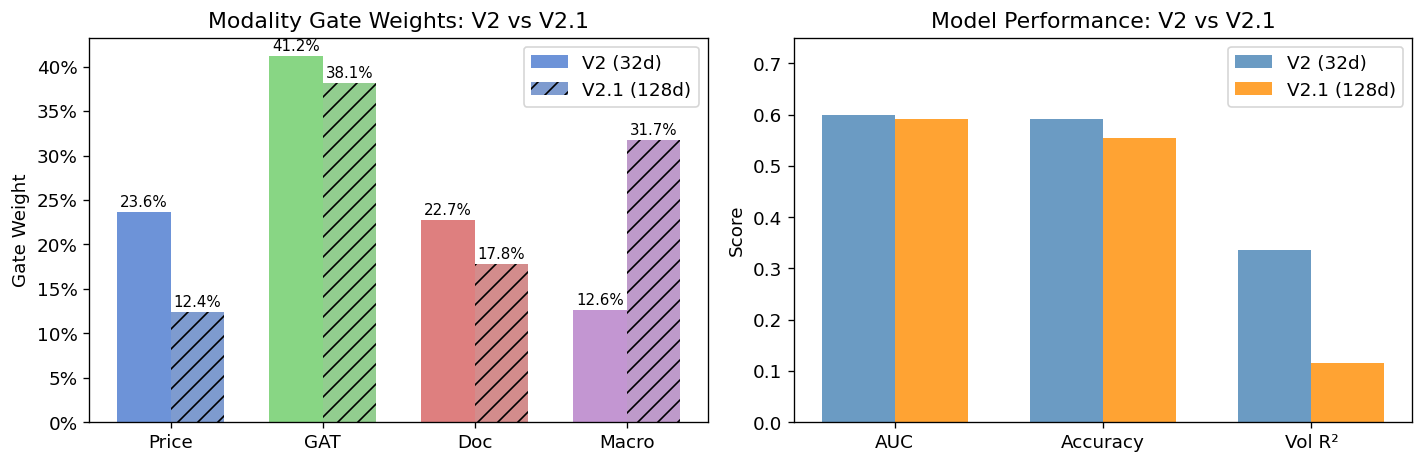

Figure saved to models/phase11_v2_comparison.png


In [3]:
# Bar chart: Gate weight comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modalities = ['Price', 'GAT', 'Doc', 'Macro']
v2_gates   = [v2_baseline['gate_price'], v2_baseline['gate_gat'],
              v2_baseline['gate_doc'],   v2_baseline['gate_macro']]
v2_1_gates = [v2_1['gate_weights']['price'], v2_1['gate_weights']['gat'],
              v2_1['gate_weights']['doc'],   v2_1['gate_weights']['macro']]

x = np.arange(len(modalities))
width = 0.35
colors_v2   = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']
colors_v2_1 = ['#2958AF', '#4AAC45', '#B63F3F', '#9457A7']

ax = axes[0]
bars1 = ax.bar(x - width/2, v2_gates,   width, label='V2 (32d)', color=colors_v2, alpha=0.8)
bars2 = ax.bar(x + width/2, v2_1_gates, width, label='V2.1 (128d)', color=colors_v2_1, alpha=0.6, hatch='//')
ax.set_xticks(x)
ax.set_xticklabels(modalities)
ax.set_ylabel('Gate Weight')
ax.set_title('Modality Gate Weights: V2 vs V2.1')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9)

# Bar chart: AUC / Acc comparison
ax2 = axes[1]
metrics  = ['AUC', 'Accuracy', 'Vol R²']
v2_vals  = [v2_baseline['auc'], v2_baseline['acc'], v2_baseline['vol_r2']]
v2_1_vals = [v2_1['direction_auc'], v2_1['direction_acc'], v2_1['vol_r2']]

x2 = np.arange(len(metrics))
ax2.bar(x2 - width/2, v2_vals,   width, label='V2 (32d)',   color='steelblue', alpha=0.8)
ax2.bar(x2 + width/2, v2_1_vals, width, label='V2.1 (128d)', color='darkorange', alpha=0.8)
ax2.set_xticks(x2)
ax2.set_xticklabels(metrics)
ax2.set_ylabel('Score')
ax2.set_title('Model Performance: V2 vs V2.1')
ax2.legend()
ax2.set_ylim(0, 0.75)

plt.tight_layout()
plt.savefig('../models/phase11_v2_comparison.png', bbox_inches='tight')
plt.show()
print('Figure saved to models/phase11_v2_comparison.png')

## 2. Phase 11A: Confidence Filtering

Confidence threshold sweep on both V2 and V2.1 fusion models.
A sample is kept only if `max(P(UP), P(DOWN)) ≥ threshold`.

In [4]:
# Build confidence filtering dataframes
def conf_results_to_df(res, label):
    rows = []
    for entry in res['sweep']:
        rows.append({
            'Model': label,
            'Threshold': entry['threshold'],
            'N': entry['N'],
            'Coverage': entry['coverage_pct'] / 100.0,
            'AUC': entry.get('auc', float('nan')),
            'Acc': entry.get('accuracy', float('nan')),
            'F1': entry.get('f1', float('nan')),
        })
    return pd.DataFrame(rows)

df_conf_v2   = conf_results_to_df(res_conf_v2,   'V2')
df_conf_v2_1 = conf_results_to_df(res_conf_v2_1, 'V2.1')

print('=== V2 Confidence Filtering Sweep ===')
print(df_conf_v2[['Threshold','N','Coverage','AUC','Acc','F1']].to_string(index=False, float_format='{:.4f}'.format))
print()
print('=== V2.1 Confidence Filtering Sweep ===')
print(df_conf_v2_1[['Threshold','N','Coverage','AUC','Acc','F1']].to_string(index=False, float_format='{:.4f}'.format))

=== V2 Confidence Filtering Sweep ===
 Threshold    N  Coverage    AUC    Acc     F1
    0.5000 9520    1.0000 0.6149 0.4773 0.3875
    0.5200 6172    0.6483 0.6066 0.4695 0.2171
    0.5400 4476    0.4702 0.5884 0.4580 0.0226
    0.5500 4058    0.4263 0.5940 0.4584 0.0000
    0.5600 3690    0.3876 0.5730 0.4764 0.0000
    0.5700 3266    0.3431 0.5545 0.4936 0.0000
    0.5800 2888    0.3034 0.5137 0.5180 0.0000
    0.6000 2028    0.2130 0.4940 0.5276 0.0000
    0.6200 1250    0.1313 0.5239 0.5184 0.0000
    0.6500  228    0.0239 0.5031 0.5614 0.0000
    0.7000    0    0.0000    NaN    NaN    NaN

=== V2.1 Confidence Filtering Sweep ===
 Threshold    N  Coverage    AUC    Acc     F1
    0.5000 9520    1.0000 0.5918 0.5544 0.5944
    0.5200 8216    0.8630 0.6001 0.5565 0.5909
    0.5400 6934    0.7284 0.6068 0.5509 0.5645
    0.5500 6286    0.6603 0.6091 0.5415 0.5338
    0.5600 5588    0.5870 0.6126 0.5311 0.4938
    0.5700 4906    0.5153 0.6070 0.5177 0.4315
    0.5800 4184    0.4395 0.

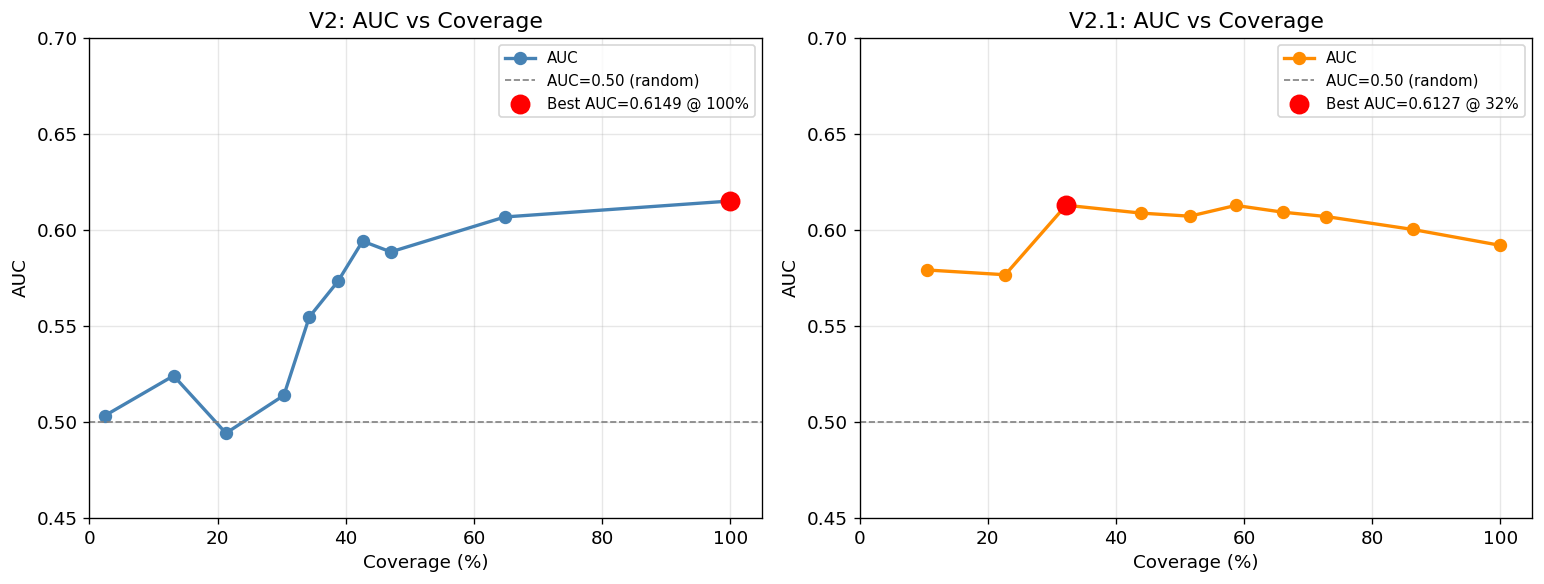

Figure saved to models/phase11_confidence_sweep.png


In [5]:
# Plot: AUC vs Coverage for V2 and V2.1
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, df, label, color in [
    (axes[0], df_conf_v2,   'V2',   'steelblue'),
    (axes[1], df_conf_v2_1, 'V2.1', 'darkorange'),
]:
    valid = df.dropna(subset=['AUC'])
    ax.plot(valid['Coverage']*100, valid['AUC'], 'o-', color=color, linewidth=2, markersize=7, label='AUC')
    ax.axhline(0.50, color='gray', linestyle='--', linewidth=1, label='AUC=0.50 (random)')

    # Mark best AUC
    best_idx = valid['AUC'].idxmax()
    best_row = valid.loc[best_idx]
    ax.scatter([best_row['Coverage']*100], [best_row['AUC']],
               color='red', zorder=5, s=120, label=f"Best AUC={best_row['AUC']:.4f} @ {best_row['Coverage']*100:.0f}%")

    ax.set_xlabel('Coverage (%)')
    ax.set_ylabel('AUC')
    ax.set_title(f'{label}: AUC vs Coverage')
    ax.legend(fontsize=9)
    ax.set_xlim(0, 105)
    ax.set_ylim(0.45, 0.70)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../models/phase11_confidence_sweep.png', bbox_inches='tight')
plt.show()
print('Figure saved to models/phase11_confidence_sweep.png')

In [6]:
# Summary: best results for each model
def best_conf_result(df, model_label):
    valid = df.dropna(subset=['AUC'])
    full  = valid[valid['Coverage'] >= 0.999].iloc[0] if len(valid[valid['Coverage'] >= 0.999]) else valid.iloc[0]
    best  = valid.loc[valid['AUC'].idxmax()]
    print(f'{model_label} Full coverage (thresh=0.50): AUC={full["AUC"]:.4f}, Acc={full["Acc"]:.4f}, F1={full["F1"]:.4f}')
    print(f'{model_label} Best AUC (thresh={best["Threshold"]:.2f}): AUC={best["AUC"]:.4f}, Acc={best["Acc"]:.4f}, Coverage={best["Coverage"]*100:.1f}%')
    print()

print('=== Confidence Filtering Summary ===')
best_conf_result(df_conf_v2,   'V2  ')
best_conf_result(df_conf_v2_1, 'V2.1')

=== Confidence Filtering Summary ===
V2   Full coverage (thresh=0.50): AUC=0.6149, Acc=0.4773, F1=0.3875
V2   Best AUC (thresh=0.50): AUC=0.6149, Acc=0.4773, Coverage=100.0%

V2.1 Full coverage (thresh=0.50): AUC=0.5918, Acc=0.5544, F1=0.5944
V2.1 Best AUC (thresh=0.60): AUC=0.6127, Acc=0.4922, Coverage=32.2%



## 3. Phase 11C: Weekly Long-Short Backtest

In [7]:
# Build backtest summary DataFrame
bt_rows = []
for sizing in ['equal_weight', 'confidence_weighted']:
    for cost_str, metrics in res_backtest[sizing].items():
        bt_rows.append({
            'Sizing': 'Equal' if sizing == 'equal_weight' else 'Conf-Weighted',
            'Cost (bps)': int(cost_str),
            'Total Return': metrics['total_return'],
            'Annual Return': metrics['annual_return'],
            'Sharpe': metrics['sharpe'],
            'Max Drawdown': metrics['max_drawdown'],
            'Win Rate': metrics['win_rate'],
            'Avg Turnover': metrics['avg_turnover'],
        })

df_bt = pd.DataFrame(bt_rows).sort_values(['Sizing', 'Cost (bps)'])

# Compute break-even costs
def compute_break_even(res, sizing):
    for cost in sorted(res[sizing].keys(), key=int):
        if res[sizing][cost]['total_return'] <= 0:
            return int(cost)
    return None

ew_break_even = compute_break_even(res_backtest, 'equal_weight')
cw_break_even = compute_break_even(res_backtest, 'confidence_weighted')

# Format for display
df_display = df_bt.copy()
df_display['Total Return'] = df_display['Total Return'].map('{:.1%}'.format)
df_display['Annual Return'] = df_display['Annual Return'].map('{:.1%}'.format)
df_display['Sharpe'] = df_display['Sharpe'].map('{:.3f}'.format)
df_display['Max Drawdown'] = df_display['Max Drawdown'].map('{:.1%}'.format)
df_display['Win Rate'] = df_display['Win Rate'].map('{:.1%}'.format)
df_display['Avg Turnover'] = df_display['Avg Turnover'].map('{:.1%}'.format)

print('=== Weekly Long-Short Backtest Results (V2 Model) ===')
print(f'Test period: 2024-01-02 to 2025-11-21')
print(f'Universe: 10 tickers, Top-2 Long / Bottom-2 Short')
print(f'Rebalance: Every 5 trading days (weekly)')
print()
print(df_display.to_string(index=False))
print()
print(f'Break-even cost (equal weight):      {ew_break_even if ew_break_even is not None else "> 20"} bps')
print(f'Break-even cost (confidence-weighted): {cw_break_even if cw_break_even is not None else "> 20"} bps')

=== Weekly Long-Short Backtest Results (V2 Model) ===
Test period: 2024-01-02 to 2025-11-21
Universe: 10 tickers, Top-2 Long / Bottom-2 Short
Rebalance: Every 5 trading days (weekly)

       Sizing  Cost (bps) Total Return Annual Return Sharpe Max Drawdown Win Rate Avg Turnover
Conf-Weighted           0         6.7%          4.3%  0.063       -18.9%    51.9%        20.3%
Conf-Weighted           5         5.1%          3.3%  0.009       -19.3%    51.9%        20.3%
Conf-Weighted          10         3.4%          2.2% -0.045       -19.7%    51.9%        20.3%
Conf-Weighted          20         0.3%          0.2% -0.154       -20.6%    49.4%        20.3%
        Equal           0        10.4%          6.7%  0.180       -19.0%    51.9%        20.3%
        Equal           5         8.7%          5.6%  0.123       -19.4%    50.6%        20.3%
        Equal          10         7.0%          4.5%  0.067       -19.8%    50.6%        20.3%
        Equal          20         3.7%          2.4% -0.

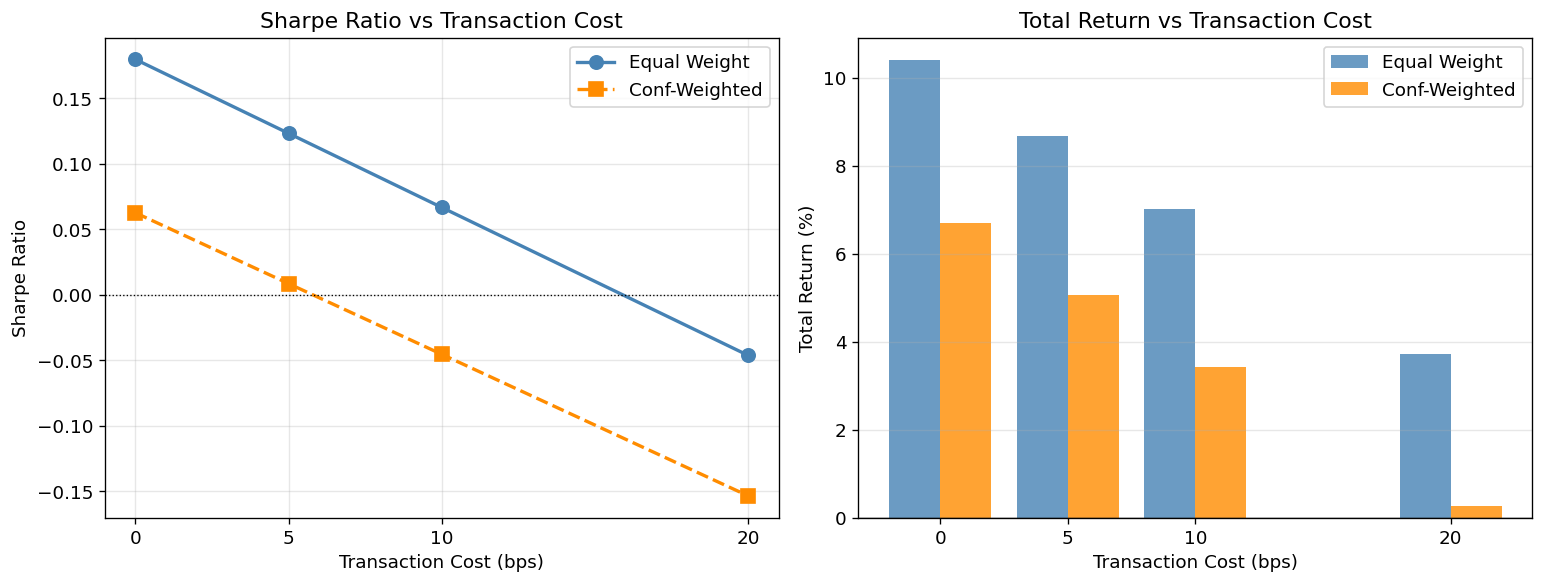

Figure saved to models/phase11_backtest_chart.png


In [8]:
# Plot: Sharpe ratio vs Transaction Cost for both sizing methods
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

costs = [0, 5, 10, 20]

# Sharpe vs cost
ax = axes[0]
ew_sharpes  = [res_backtest['equal_weight'][str(c)]['sharpe'] for c in costs]
cw_sharpes  = [res_backtest['confidence_weighted'][str(c)]['sharpe'] for c in costs]
ax.plot(costs, ew_sharpes, 'o-', color='steelblue', linewidth=2, markersize=8, label='Equal Weight')
ax.plot(costs, cw_sharpes, 's--', color='darkorange', linewidth=2, markersize=8, label='Conf-Weighted')
ax.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax.set_xlabel('Transaction Cost (bps)')
ax.set_ylabel('Sharpe Ratio')
ax.set_title('Sharpe Ratio vs Transaction Cost')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xticks(costs)

# Total return vs cost
ax2 = axes[1]
ew_returns  = [res_backtest['equal_weight'][str(c)]['total_return']*100 for c in costs]
cw_returns  = [res_backtest['confidence_weighted'][str(c)]['total_return']*100 for c in costs]
ax2.bar(np.array(costs)-1, ew_returns, width=2, color='steelblue', alpha=0.8, label='Equal Weight')
ax2.bar(np.array(costs)+1, cw_returns, width=2, color='darkorange', alpha=0.8, label='Conf-Weighted')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Transaction Cost (bps)')
ax2.set_ylabel('Total Return (%)')
ax2.set_title('Total Return vs Transaction Cost')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')
ax2.set_xticks(costs)

plt.tight_layout()
plt.savefig('../models/phase11_backtest_chart.png', bbox_inches='tight')
plt.show()
print('Figure saved to models/phase11_backtest_chart.png')

## 4. Phase 11 Master Summary

In [9]:
print('=' * 65)
print('PHASE 11 MASTER SUMMARY')
print('=' * 65)

print()
print('--- AUC Progression ---')
print(f"  V2  (macro 32d,  full coverage):  AUC = 0.5989")
print(f"  V2.1 (macro 128d, full coverage): AUC = {v2_1['direction_auc']:.4f}  (Δ={v2_1['direction_auc']-0.5989:+.4f})")

# Best confidence-filtered AUC
v2_best_conf_row   = df_conf_v2.dropna(subset=['AUC']).loc[df_conf_v2.dropna(subset=['AUC'])['AUC'].idxmax()]
v2_1_best_conf_row = df_conf_v2_1.dropna(subset=['AUC']).loc[df_conf_v2_1.dropna(subset=['AUC'])['AUC'].idxmax()]

print(f"  V2  @thresh={v2_best_conf_row['Threshold']:.2f} ({v2_best_conf_row['Coverage']*100:.0f}% cov): AUC = {v2_best_conf_row['AUC']:.4f}")
print(f"  V2.1 @thresh={v2_1_best_conf_row['Threshold']:.2f} ({v2_1_best_conf_row['Coverage']*100:.0f}% cov): AUC = {v2_1_best_conf_row['AUC']:.4f}")

print()
print('--- Macro Encoder Expansion Impact ---')
print(f"  Macro gate weight:  V2={v2_baseline['gate_macro']:.1%}  →  V2.1={v2_1['gate_weights']['macro']:.1%}  (+{v2_1['gate_weights']['macro']-v2_baseline['gate_macro']:.1%})")
print(f"  Vol R²:             V2={v2_baseline['vol_r2']:.4f}  →  V2.1={v2_1['vol_r2']:.4f}  ({v2_1['vol_r2']-v2_baseline['vol_r2']:+.4f})")
print(f"  Note: AUC slightly decreased ({v2_1['direction_auc']-0.5989:+.4f}); macro expansion improved gate")
print(f"        weight engagement but did not improve directional accuracy.")

print()
print('--- Confidence Filtering Findings ---')
print(f"  V2:   Filtering does NOT improve AUC (best at 100% coverage)")
print(f"  V2.1: Filtering improves AUC: {df_conf_v2_1.iloc[0]['AUC']:.4f} → {v2_1_best_conf_row['AUC']:.4f} at {v2_1_best_conf_row['Coverage']*100:.0f}% coverage")
print(f"  V2.1 model is better calibrated — has meaningful confidence variation.")

print()
print('--- Weekly Backtest (V2 Model, Test Set) ---')
bt_ew_0  = res_backtest['equal_weight']['0']
bt_ew_10 = res_backtest['equal_weight']['10']
print(f"  Period: {bt_ew_0['n_trading_days']} trading days, {bt_ew_0['n_rebalances']} weekly rebalances")
print(f"  0 bp:   total={bt_ew_0['total_return']*100:.1f}%, sharpe={bt_ew_0['sharpe']:.3f}, win={bt_ew_0['win_rate']*100:.1f}%")
print(f"  10 bp:  total={bt_ew_10['total_return']*100:.1f}%, sharpe={bt_ew_10['sharpe']:.3f}, win={bt_ew_10['win_rate']*100:.1f}%")
print(f"  Break-even cost: {ew_break_even if ew_break_even is not None else '> 20'} bps (equal weight)")
print(f"  Avg weekly turnover: {bt_ew_0['avg_turnover']*100:.1f}%")
print()

print('=' * 65)
print('GPU Optimization (Phase 11 Step 1):')
print('  cuDNN benchmark: ON   TF32 matmul: ON')
print('  DataLoader: num_workers=0 on Windows (spawn overhead avoidance)')
print('  FusionEmbeddingDataset.to_device(): all tensors pre-loaded to GPU')
print('  VRAM peak: 1.001 GB @ batch=4096 (model ~550K params)')
print('=' * 65)

PHASE 11 MASTER SUMMARY

--- AUC Progression ---
  V2  (macro 32d,  full coverage):  AUC = 0.5989
  V2.1 (macro 128d, full coverage): AUC = 0.5917  (Δ=-0.0072)
  V2  @thresh=0.50 (100% cov): AUC = 0.6149
  V2.1 @thresh=0.60 (32% cov): AUC = 0.6127

--- Macro Encoder Expansion Impact ---
  Macro gate weight:  V2=12.6%  →  V2.1=31.7%  (+19.1%)
  Vol R²:             V2=0.3350  →  V2.1=0.1154  (-0.2196)
  Note: AUC slightly decreased (-0.0072); macro expansion improved gate
        weight engagement but did not improve directional accuracy.

--- Confidence Filtering Findings ---
  V2:   Filtering does NOT improve AUC (best at 100% coverage)
  V2.1: Filtering improves AUC: 0.5918 → 0.6127 at 32% coverage
  V2.1 model is better calibrated — has meaningful confidence variation.

--- Weekly Backtest (V2 Model, Test Set) ---
  Period: 384 trading days, 96 weekly rebalances
  0 bp:   total=10.4%, sharpe=0.180, win=51.9%
  10 bp:  total=7.0%, sharpe=0.067, win=50.6%
  Break-even cost: > 20 bps (e

## 5. Full AUC Progression (Phases 1 → 11)

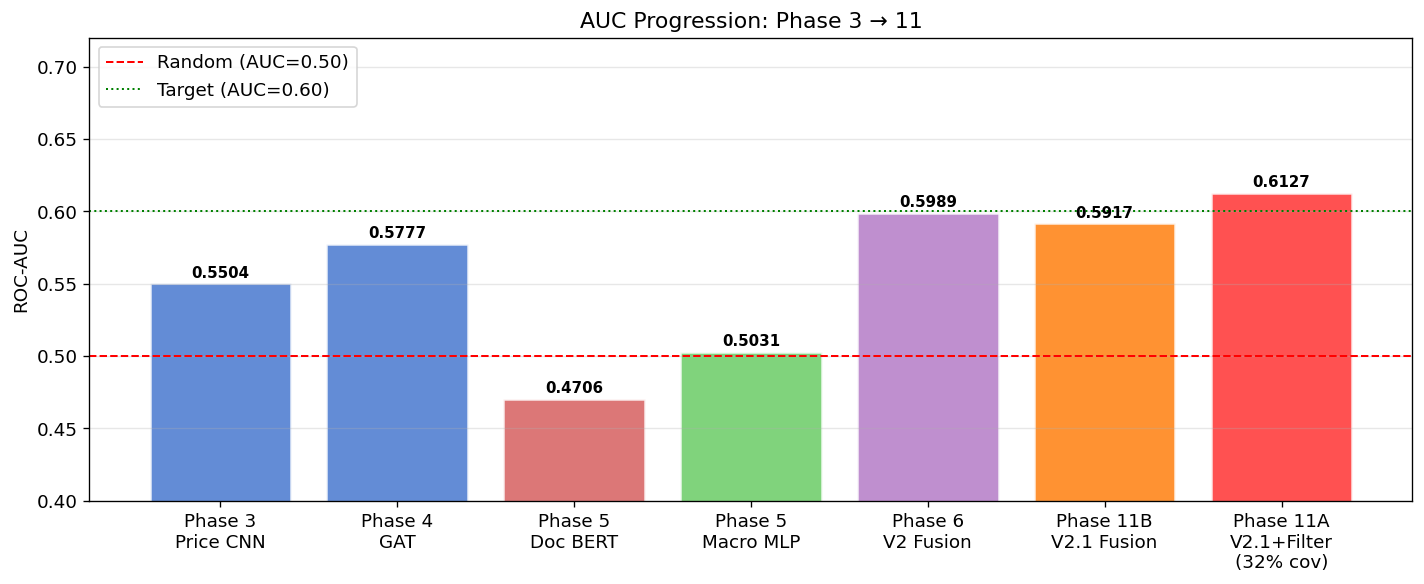

Figure saved to models/phase11_auc_progression.png


In [10]:
# AUC progression across all phases
auc_history = [
    ('Phase 3\nPrice CNN', 0.5504),
    ('Phase 4\nGAT',       0.5777),
    ('Phase 5\nDoc BERT',  0.4706),
    ('Phase 5\nMacro MLP', 0.5031),
    ('Phase 6\nV2 Fusion', 0.5989),
    ('Phase 11B\nV2.1 Fusion', v2_1['direction_auc']),
    (f'Phase 11A\nV2.1+Filter\n({v2_1_best_conf_row["Coverage"]*100:.0f}% cov)', v2_1_best_conf_row['AUC']),
]

labels = [x[0] for x in auc_history]
aucs   = [x[1] for x in auc_history]
colors = ['#4878CF', '#4878CF', '#D65F5F', '#6ACC65', '#B47CC7', '#FF7F0E', '#FF3333']

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(labels, aucs, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axhline(0.50, color='red', linestyle='--', linewidth=1.2, label='Random (AUC=0.50)')
ax.axhline(0.60, color='green', linestyle=':', linewidth=1.2, label='Target (AUC=0.60)')
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
            f'{auc:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('ROC-AUC')
ax.set_ylim(0.40, 0.72)
ax.set_title('AUC Progression: Phase 3 → 11')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../models/phase11_auc_progression.png', bbox_inches='tight')
plt.show()
print('Figure saved to models/phase11_auc_progression.png')